## CausalMix complete experiments for three scenarios


## ⚠️ Dependency Note

This notebook assumes that `01_setup_data.ipynb` has been executed
in the same Python session.

The setup notebook defines:
- Data loading 
- Metadata information (variable types and levels)
- Shared configuration variables

If running this notebook independently, please execute
`01_setup_data.ipynb` first.

In [0]:
m1 = CausalMix(
    data = mcrpc_data,  
    post_treatment_var = ["hosp_ed_any"],  
    treatment_var = ["exp"],  
    binary_var = binary_var, 
    categorical_var = categorical_var,  
    numerical_var = numerical_var,  
    integer_var = numerical_var, 
    categorical_dims=unique_levels,      
    var_bounds={},  
)

In [0]:
# Scenario 1: homogeneous treatment effect, no unmeasured confounding, perfect overlap
def treatment_effect_fn(x, index):
    # X is a torch.Tensor of features excluding treatment
    return 0.1  # effect differs by the first variable (binary)

def selection_bias_fn(x, t, index):
    # latent risk constructed from observable X
    return 0

def overlap_fn(x, index):
    return 0

In [0]:
m1.fit(
    treatment_effect_fn=treatment_effect_fn,
    selection_bias_fn=selection_bias_fn,
    overlap_target=overlap_fn,
    effect_rigidity=1e3,
    effect_mse_weight=0.3, # effect blend weight on MSE
    effect_var_weight=2e-1, # variance penalty for treatment effect residuals
    bias_rigidity=1e3,
    bias_mse_weight=0.3, # bias blend weight on MSE
    bias_var_weight=2e-2, # variance penalty for bias residuals
    overlap_weight = 1e1,
    )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │  1.2 K │ train │     0 │
│ 1 │ en_mu        │ Linear     │  1.2 K │ train │     0 │
│ 2 │ en_logvar    │ Linear     │  1.2 K │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.3 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │  1.5 K │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │  1.2 K │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 7.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 48                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/util

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │    128 │ train │     0 │
│ 1 │ en_mu        │ Linear     │    130 │ train │     0 │
│ 2 │ en_logvar    │ Linear     │    130 │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.4 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │    130 │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │    130 │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



[exp    0.570278
 dtype: float64,
 conVAE(
   (encoder): Sequential(
     (0): Sequential(
       (0): Linear(in_features=18, out_features=64, bias=True)
       (1): LeakyReLU(negative_slope=0.01)
     )
   )
   (en_mu): Linear(in_features=64, out_features=18, bias=True)
   (en_logvar): Linear(in_features=64, out_features=18, bias=True)
   (decoder): Sequential(
     (0): Sequential(
       (0): Linear(in_features=19, out_features=64, bias=True)
       (1): LeakyReLU(negative_slope=0.01)
     )
   )
   (output_heads): ModuleDict(
     (0): Linear(in_features=64, out_features=1, bias=True)
     (1): Linear(in_features=64, out_features=1, bias=True)
     (2): Linear(in_features=64, out_features=1, bias=True)
     (3): Linear(in_features=64, out_features=1, bias=True)
     (4): Linear(in_features=64, out_features=1, bias=True)
     (5): Linear(in_features=64, out_features=1, bias=True)
     (6): Linear(in_features=64, out_features=1, bias=True)
     (7): Linear(in_features=64, out_feature

In [0]:
# Last logged validation loss from the final epoch
last_val_X = m1.m_pre.trainer.callback_metrics.get("val_loss")
print("Last val_loss for X:", float(last_val_X) if last_val_X is not None else "N/A")
last_val_Y = m1.m_post.trainer.callback_metrics.get("val_loss")
print("Last val_loss for Y:", float(last_val_Y) if last_val_Y is not None else "N/A")

Last val_loss for X: -0.29562485218048096
Last val_loss for Y: 0.15698491036891937


Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.005, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.538, 'ps/hist_overlap_coeff': 0.938, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



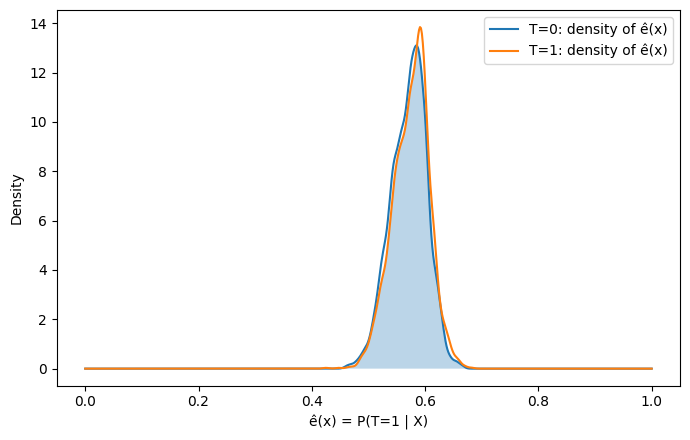

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.007, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.529, 'ps/hist_overlap_coeff': 0.956, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



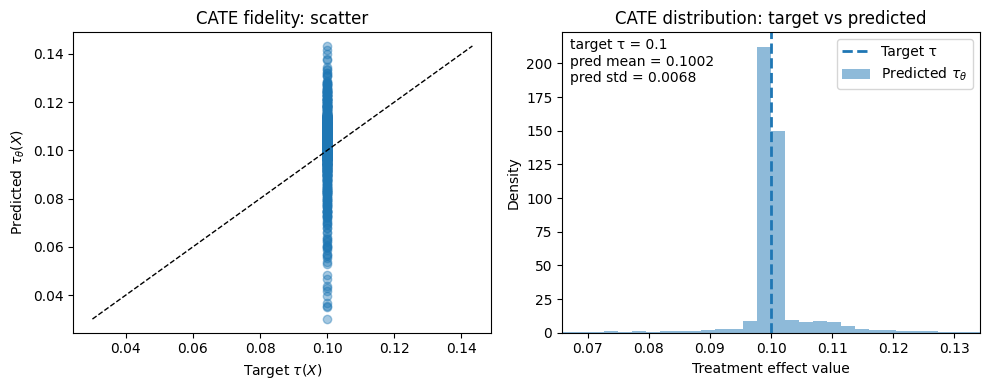

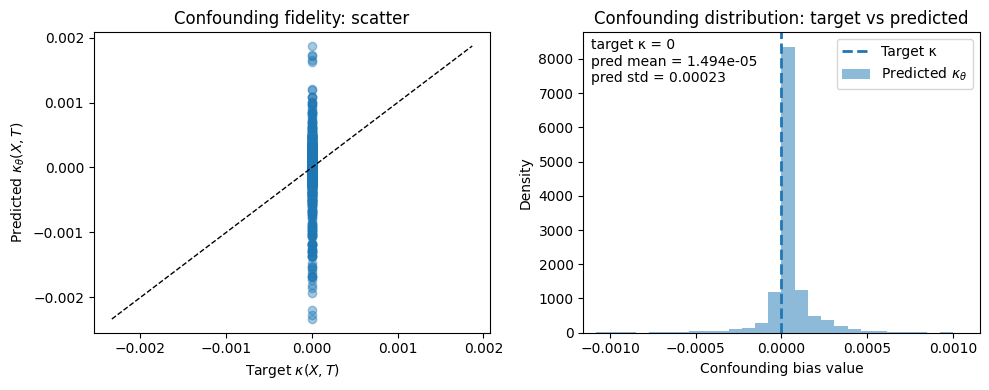

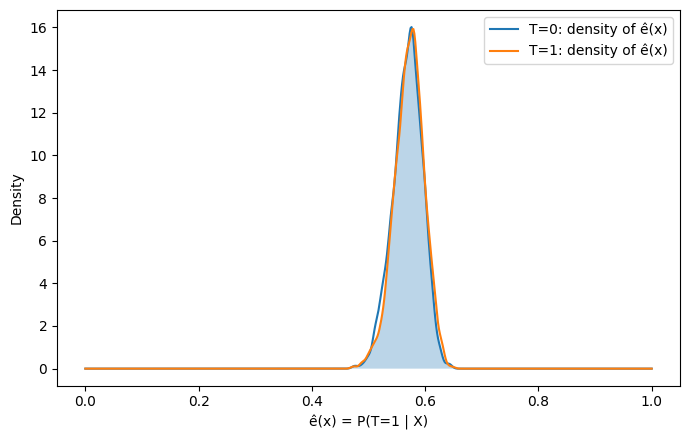

CausalEvalResults(mae_tau=0.003, corr_tau=nan, ate_pred=0.1, ate_target=0.1, ate_abs_error=0.0, tau_wasserstein=0.003, mae_kappa=0.0, mae_kappa_t0=0.0, mae_kappa_t1=0.0, kappa_wasserstein=0.0, overlap_coeff=0.94, bw0=0.022, bw1=0.022)


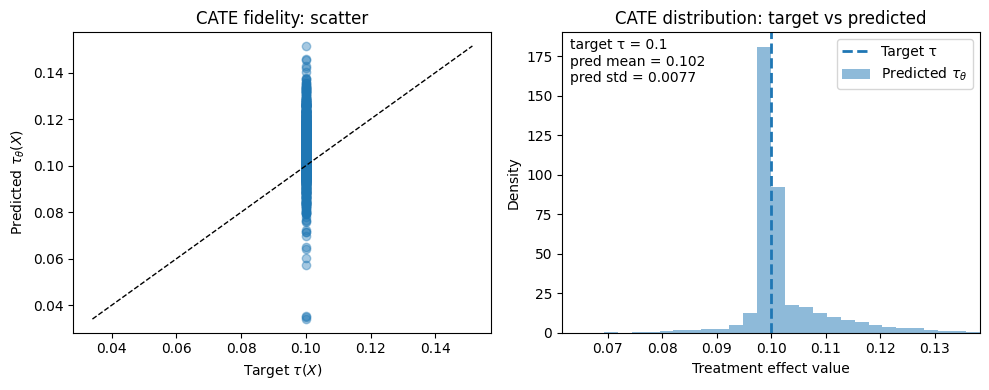

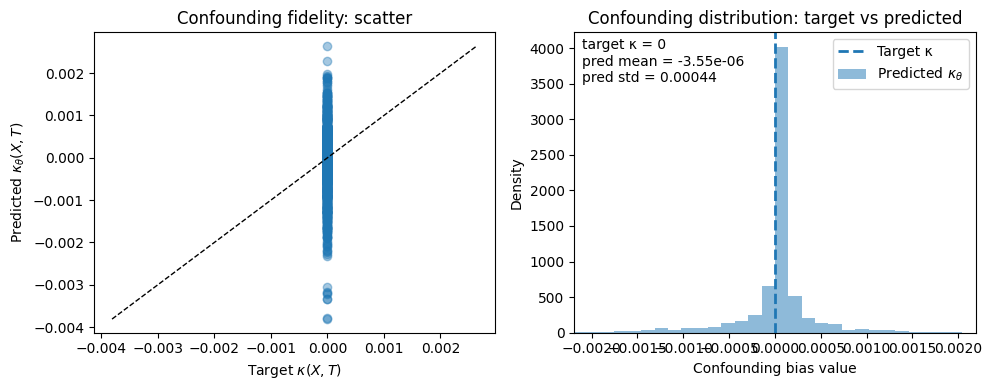

In [0]:
# generate new samples and return causal evaluation metrics
out1_bgmm = m1.causal_bgmm(
    n_samples=mcrpc_data.shape[0],
    deterministic=False,
    return_probs=False,
    plot=True,
    savepath=""
)
out1_gauss = m1.causal_gauss(
    n_samples=mcrpc_data.shape[0],
    deterministic=False,
    return_probs=False,
    plot=True,
)

cm_metrics = out1_bgmm["causal_metrics"]
df_gen = out1_bgmm["df_gen"]
df_Y = out1_bgmm["df_Y"]
df_Ymean = out1_bgmm["df_Ymean"]
df_Ymean_prime = out1_bgmm["df_Ymean_prime"] 
stats = out1_bgmm["stats"]
print(cm_metrics)

In [0]:
out1_bgmm

{'df_gen':      Abiraterone_prev Enzalutamide_prev anti_arr_pre  ...  trt_prev age Charlson
 0                   0                 0            0  ...  ADT_only  76        1
 1                   0                 0            0  ...  ADT_only  68        1
 2                   0                 0            0  ...  ADT_only  73        3
 3                   0                 0            1  ...  ADT_only  77        3
 4                   0                 0            0  ...  ADT_only  78        2
 ...               ...               ...          ...  ...       ...  ..      ...
 4093                0                 0            0  ...  ADT_only  48        1
 4094                0                 0            1  ...  ADT_only  82        1
 4095                0                 1            1  ...      ARPI  76        4
 4096                0                 1            0  ...      ARPI  70        2
 4097                0                 0            1  ...      ARPI  64        1
 
 [40

In [0]:
# evaluation
schema = DataSchema(
    numeric = numerical_var,
    binary = binary_var,
    categorical = categorical_var
)
evaluator_bgmm = SynthEval(mcrpc_data, out1_bgmm["df_gen"], schema)
dist_bgmm = evaluator_bgmm.run_all(conditional_col = "exp")
evaluator_gauss = SynthEval(mcrpc_data, out1_gauss["df_gen"], schema)
dist_gauss = evaluator_gauss.run_all(conditional_col = "exp")

dist_all = {
    "BGMM": dist_bgmm,
    "Gaussian": dist_gauss
}
t_dist = build_table_distributional_fidelity(dist_all)
t_privacy = build_table_privacy(dist_all)

causal_all = {
    "BGMM": out1_bgmm,
    "Gaussian": out1_gauss
}
t_causal = build_table_causal_structure(causal_all)


print(t_causal)  # replaced Databricks display() with print()
print(t_dist)  # replaced Databricks display() with print()
print(t_privacy)  # replaced Databricks display() with print()

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Category,Metric,Direction,BGMM,Gaussian
Treatment Effect,CATE/ITE MAE,↓ better,0.003,0.004
Treatment Effect,CATE Correlation,↑ better,null,null
Treatment Effect,ATE Error,↓ better,0.0,0.002
Treatment Effect,TE Distribution Distance (W1),↓ better,0.003,0.004
Confounding,Confounding MAE,↓ better,0.0,0.0
Confounding,Group-wise MAE (T=0),↓ better,0.0,0.0
Confounding,Group-wise MAE (T=1),↓ better,0.0,0.0
Confounding,Confounding Dist. (W1),↓ better,0.0,0.0
Overlap (decoder),Δ vs target MSE,↓ better,0.0,0.0
Overlap (decoder),Fraction within tolerance,↑ better,1.0,1.0


Category,Metric,Direction,BGMM,Gaussian
Marginal (cont.),Normalized Wasserstein (mean),↓ better,0.07,0.334
Marginal (cont.),KSComplement (mean),↑ better,0.938,0.854
Marginal (disc.),TVComplement (mean),↑ better,0.974,0.94
Pairwise (cont–cont.),CorrelationSimilarity,↑ better,0.988,0.926
Pairwise (all vars),SU similarity (mean),↑ better,0.989,0.991
Pairwise (disc–disc.),ContingencySimilarity (mean),↑ better,0.953,0.899
Conditional (all except C),Weighted MMD$^2$,↓ better,0.004,0.008
Conditional (all except C),Normalized $MMD$^2$ ratio vs real,↓ better; 1 = real-data baseline,1.535,2.806
Joint (all vars),Normalized Energy Distance,↓ better,0.004,0.025
Joint (all vars),C2ST (AUC complement),↑ better.,0.737,0.543


Category,Metric,Direction,BGMM,Gaussian
DCR,Protection Fraction,↑ better,0.591,0.699
DCR,Distance Ratio (mean),↑ better,2.554,3.514
DCR,Distance Ratio (p5),↑ better,0.25,0.5
DCR,Distance Ratio (p50),↑ better,1.041,1.125
DCR,Distance Ratio (p95),↑ better,5.0,6.049
DCR,Standardized Distance Ratio,↑ better,0.277,0.336


Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.005, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.542, 'ps/hist_overlap_coeff': 0.935, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



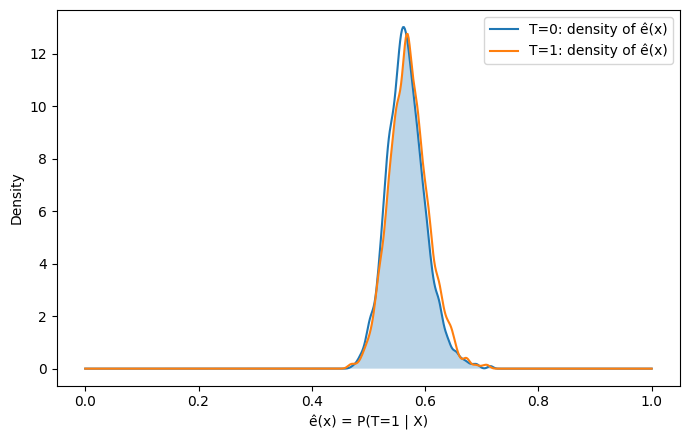

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.007, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.525, 'ps/hist_overlap_coeff': 0.96, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



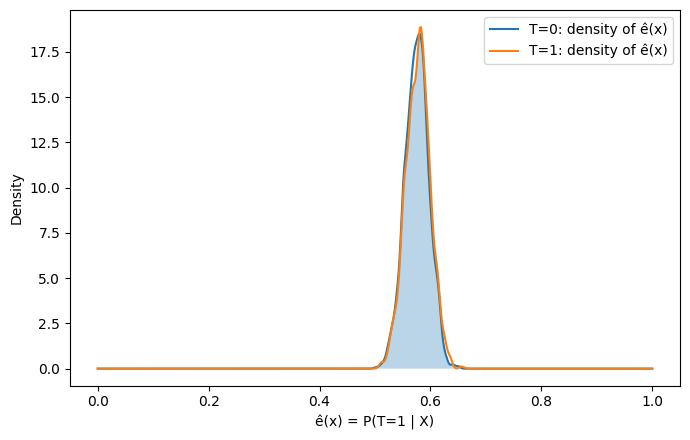

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.005, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.534, 'ps/hist_overlap_coeff': 0.947, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



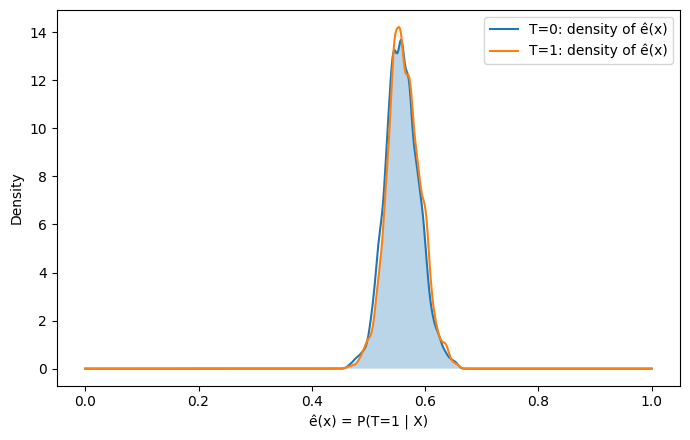

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.007, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.552, 'ps/hist_overlap_coeff': 0.912, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



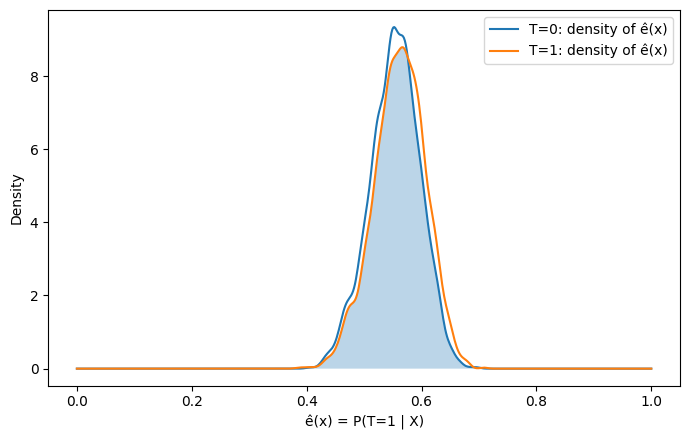

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.005, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.532, 'ps/hist_overlap_coeff': 0.952, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



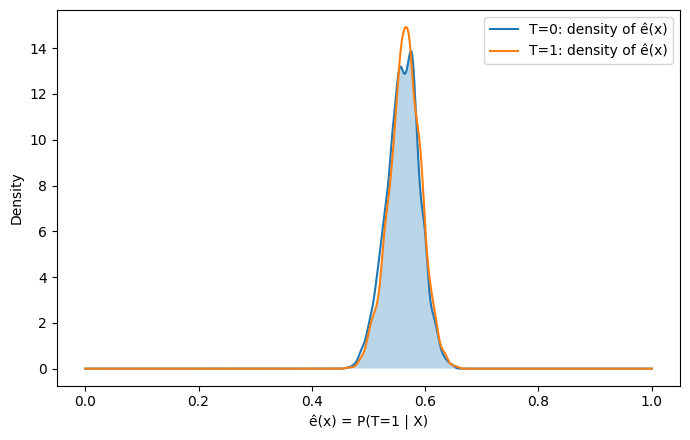

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.008, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.537, 'ps/hist_overlap_coeff': 0.954, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



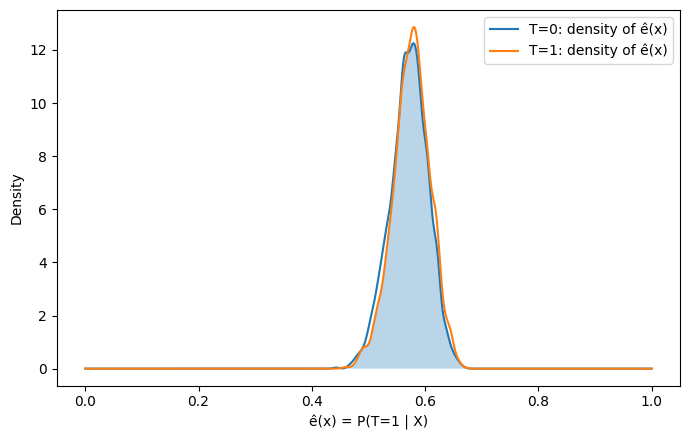

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.005, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.534, 'ps/hist_overlap_coeff': 0.952, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



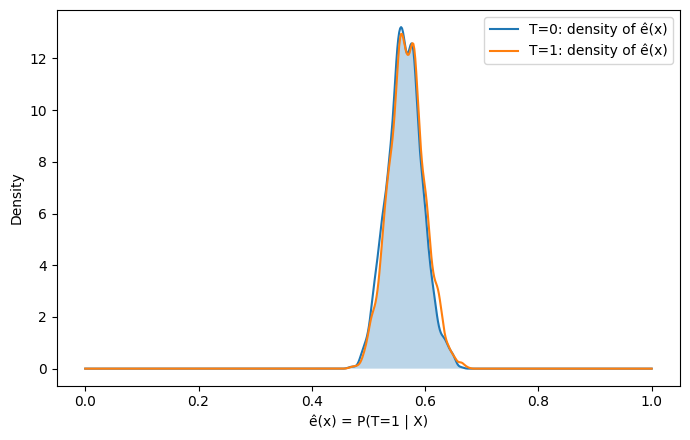

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.007, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.53, 'ps/hist_overlap_coeff': 0.958, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



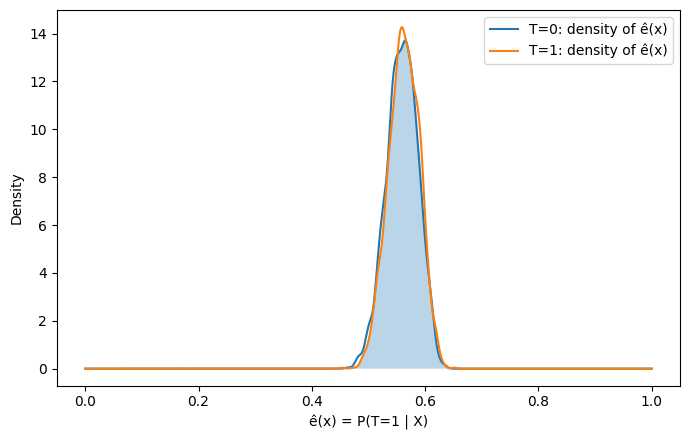

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.005, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.53, 'ps/hist_overlap_coeff': 0.965, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



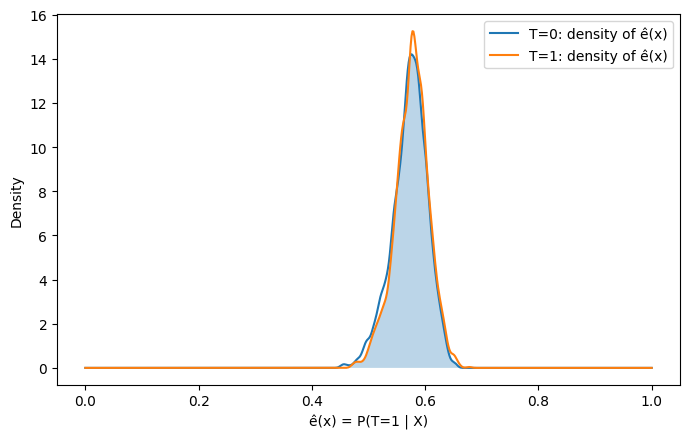

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.008, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.537, 'ps/hist_overlap_coeff': 0.953, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



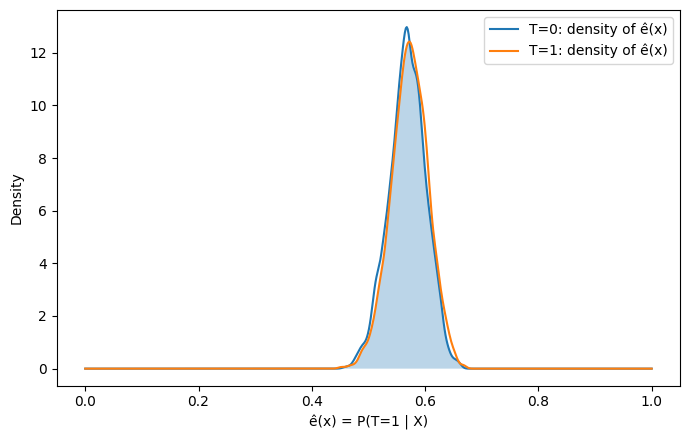

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.005, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.543, 'ps/hist_overlap_coeff': 0.935, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



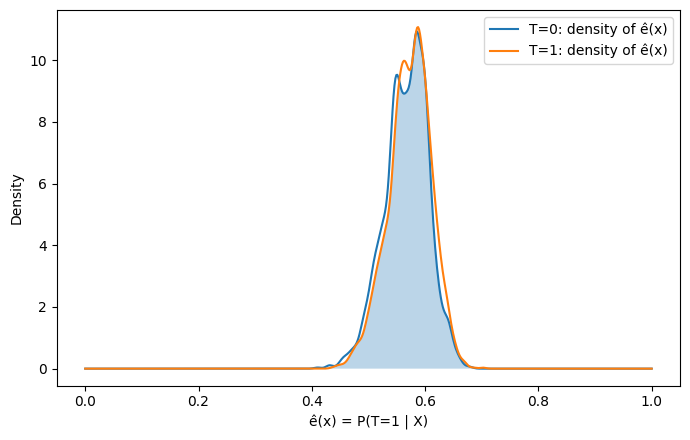

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.008, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.539, 'ps/hist_overlap_coeff': 0.937, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



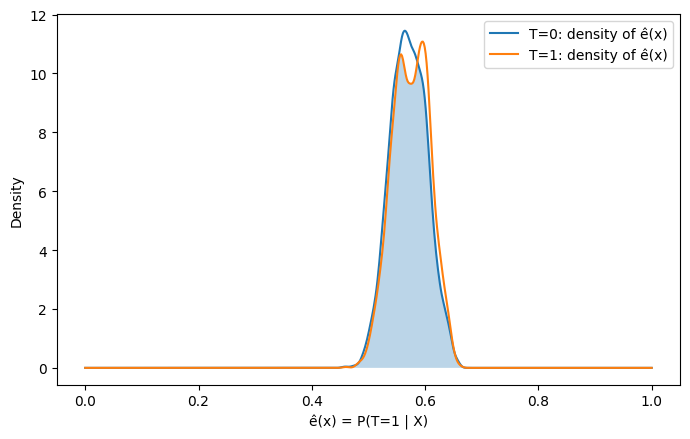

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.005, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.542, 'ps/hist_overlap_coeff': 0.939, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



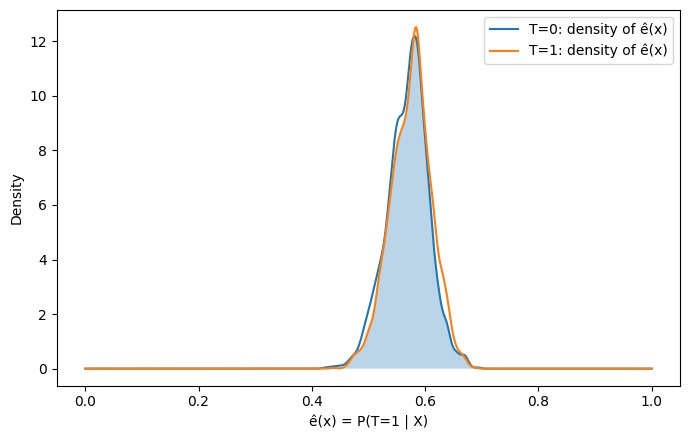

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.008, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.533, 'ps/hist_overlap_coeff': 0.946, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



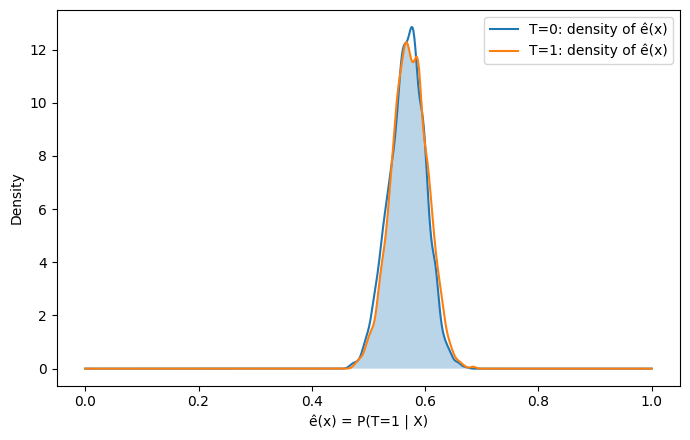

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.005, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.553, 'ps/hist_overlap_coeff': 0.9, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



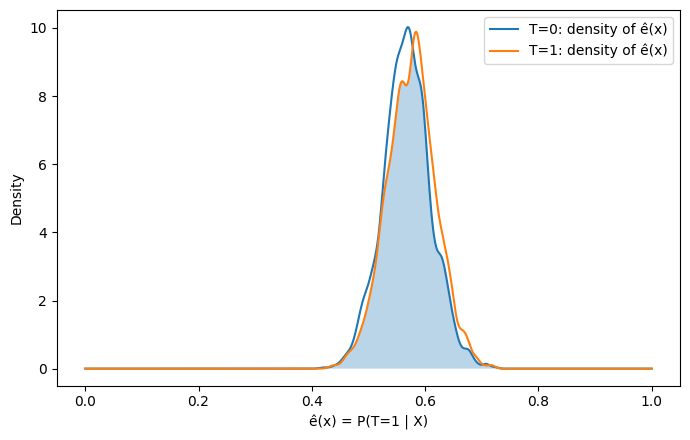

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.008, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.536, 'ps/hist_overlap_coeff': 0.937, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



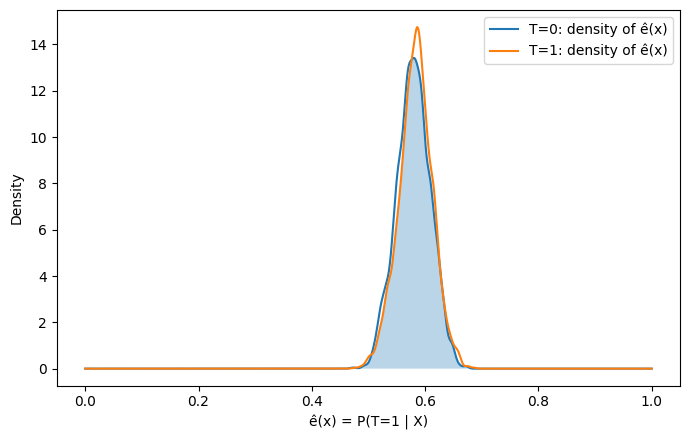

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.005, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.539, 'ps/hist_overlap_coeff': 0.941, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



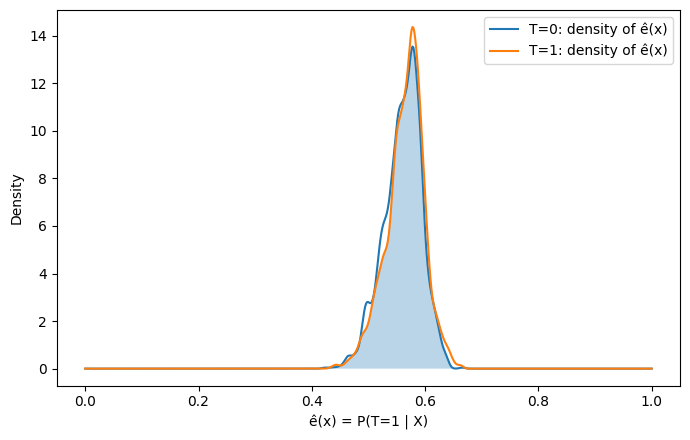

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.007, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.527, 'ps/hist_overlap_coeff': 0.961, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



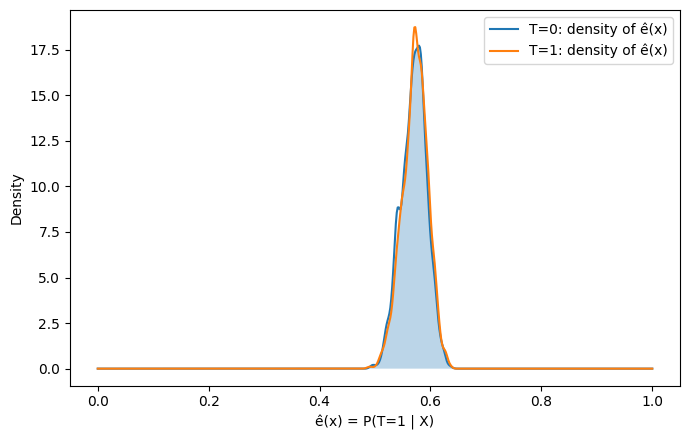

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.005, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.54, 'ps/hist_overlap_coeff': 0.933, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



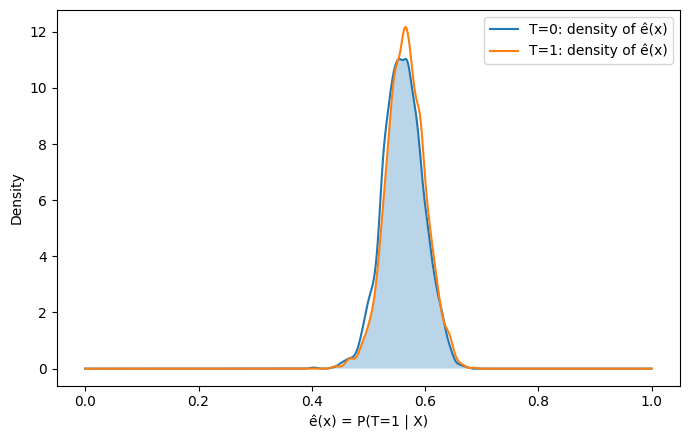

Overlap metrics: {'dec/log_ratio_mean': -0.001, 'dec/log_ratio_std': 0.007, 'dec/target_mean': 0.0, 'dec/target_std': 0.0, 'dec/mse_to_target': 0.0, 'dec/fraction_within_tol': 1.0, 'ps/auc': 0.54, 'ps/hist_overlap_coeff': 0.947, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



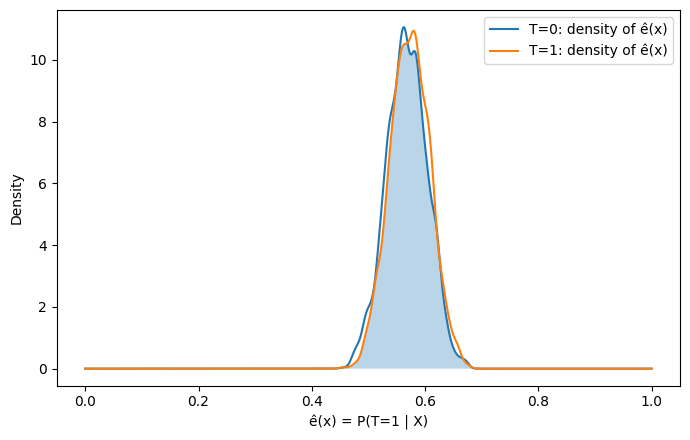

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Category,Metric,Direction,BGMM,Gaussian
Treatment Effect,CATE/ITE MAE,↓ better,0.003 (0.000),0.004 (0.000)
Treatment Effect,CATE Correlation,↑ better,,
Treatment Effect,ATE Error,↓ better,0.000 (0.000),0.002 (0.000)
Treatment Effect,TE Distribution Distance (W1),↓ better,0.003 (0.000),0.004 (0.000)
Confounding,Confounding MAE,↓ better,0.000 (0.000),0.000 (0.000)
Confounding,Group-wise MAE (T=0),↓ better,0.000 (0.000),0.000 (0.000)
Confounding,Group-wise MAE (T=1),↓ better,0.000 (0.000),0.000 (0.000)
Confounding,Confounding Dist. (W1),↓ better,0.000 (0.000),0.000 (0.000)
Overlap (decoder),Δ vs target MSE,↓ better,0.000 (0.000),0.000 (0.000)
Overlap (decoder),Fraction within tolerance,↑ better,1.000 (0.000),1.000 (0.000)


Category,Metric,Direction,BGMM,Gaussian
Marginal (cont.),Normalized Wasserstein (mean),↓ better,0.071 (0.001),0.336 (0.010)
Marginal (cont.),KSComplement (mean),↑ better,0.939 (0.001),0.853 (0.006)
Marginal (disc.),TVComplement (mean),↑ better,0.973 (0.001),0.939 (0.001)
Pairwise (cont–cont.),CorrelationSimilarity,↑ better,0.987 (0.002),0.915 (0.005)
Pairwise (all vars),SU similarity (mean),↑ better,0.994 (0.002),0.992 (0.000)
Pairwise (disc–disc.),ContingencySimilarity (mean),↑ better,0.953 (0.001),0.899 (0.002)
Conditional (all except C),Weighted MMD$^2$,↓ better,0.004 (0.001),0.007 (0.002)
Conditional (all except C),Normalized $MMD$^2$ ratio vs real,↓ better; 1 = real-data baseline,1.533 (0.154),2.531 (0.601)
Joint (all vars),Normalized Energy Distance,↓ better,0.004 (0.001),0.025 (0.001)
Joint (all vars),C2ST (AUC complement),↑ better.,0.748 (0.009),0.551 (0.013)


Category,Metric,Direction,BGMM,Gaussian
DCR,Protection Fraction,↑ better,0.595 (0.009),0.696 (0.008)
DCR,Distance Ratio (mean),↑ better,2.535 (0.083),3.254 (0.163)
DCR,Distance Ratio (p5),↑ better,0.233 (0.028),0.501 (0.003)
DCR,Distance Ratio (p50),↑ better,1.039 (0.006),1.122 (0.006)
DCR,Distance Ratio (p95),↑ better,4.841 (0.263),6.150 (0.304)
DCR,Standardized Distance Ratio,↑ better,0.276 (0.003),0.333 (0.003)


---------------------------------------------------------------------------
ModuleNotFoundError                       Traceback (most recent call last)
File <command-7424738471719731>, line 88
     85 display(t_privacy_m1)
     87 # Optional: save to Excel
---> 88 with pd.ExcelWriter(output_result + "m1_tables_mean.xlsx", engine="openpyxl") as w:
     89     t_dist_m1.to_excel(w, sheet_name="DistributionalFidelity", index=False)
     90     t_privacy_m1.to_excel(w, sheet_name="Privacy", index=False)

File /databricks/python/lib/python3.10/site-packages/pandas/io/excel/_openpyxl.py:56, in OpenpyxlWriter.__init__(self, path, engine, date_format, datetime_format, mode, storage_options, if_sheet_exists, engine_kwargs, **kwargs)
     43 def __init__(
     44     self,
     45     path: FilePath | WriteExcelBuffer | ExcelWriter,
   (...)
     54 ) -> None:
     55     # Use the openpyxl module as the Excel writer.
---> 56     from openpyxl.workbook import Workbook
     58     engine_kwargs =

In [0]:
# -----------------------------------------------------------------------------------------------------------------------------
# Produce tables of Mean (sd) across generated datasets for the three tables distribution, privacy, and causal structure
# -----------------------------------------------------------------------------------------------------------------------------
schema = DataSchema(numeric=numerical_var, binary=binary_var, categorical=categorical_var)

t_causal_m1, t_dist_m1, t_privacy_m1= eval_tables_mean(
    model=m1,
    real_df=mcrpc_data,
    schema=schema,
    R=10,
    conditional_col="exp",
    plot_each_run=False,
)

print(t_causal_m1)  # replaced Databricks display() with print()
print(t_dist_m1)  # replaced Databricks display() with print()
print(t_privacy_m1)  # replaced Databricks display() with print()

# Optional: save to Excel
with pd.ExcelWriter(output_result + "m1_tables_mean.xlsx", engine="openpyxl") as w:
    t_dist_m1.to_excel(w, sheet_name="DistributionalFidelity", index=False)
    t_privacy_m1.to_excel(w, sheet_name="Privacy", index=False)
    t_causal_m1.to_excel(w, sheet_name="CausalStructure", index=False)

In [0]:
with pd.ExcelWriter(output_result + "m1_tables_mean.xlsx", engine="openpyxl") as w:
    t_dist_m1.to_excel(w, sheet_name="DistributionalFidelity", index=False)
    t_privacy_m1.to_excel(w, sheet_name="Privacy", index=False)
    t_causal_m1.to_excel(w, sheet_name="CausalStructure", index=False)

In [0]:
# # save in cvs
# t_causal.to_csv(output_result + "s1_causal.csv", index=False)
# t_dist.to_csv(output_result + "s1_dist.csv", index=False)
# t_privacy.to_csv(output_result + "s1_privacy.csv", index=False)

In [0]:
# get the code to use in overleaf
print(t_causal_m1.to_latex(index=False, escape=False, float_format="%.3f"))
print(t_dist_m1.to_latex(index=False, escape=False, float_format="%.3f"))
print(t_privacy_m1.to_latex(index=False, escape=False, float_format="%.3f"))


\begin{tabular}{lllll}
\toprule
            Category &                        Metric &                                Direction &          BGMM &      Gaussian \\
\midrule
    Treatment Effect &                  CATE/ITE MAE &                                 ↓ better & 0.003 (0.000) & 0.004 (0.000) \\
    Treatment Effect &              CATE Correlation &                                 ↑ better &               &               \\
    Treatment Effect &                     ATE Error &                                 ↓ better & 0.000 (0.000) & 0.002 (0.000) \\
    Treatment Effect & TE Distribution Distance (W1) &                                 ↓ better & 0.003 (0.000) & 0.004 (0.000) \\
         Confounding &               Confounding MAE &                                 ↓ better & 0.000 (0.000) & 0.000 (0.000) \\
         Confounding &          Group-wise MAE (T=0) &                                 ↓ better & 0.000 (0.000) & 0.000 (0.000) \\
         Confounding &          Group-wise

/root/.ipykernel/13289/command-8736129108311804-2218562734:2: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.

/root/.ipykernel/13289/command-8736129108311804-2218562734:3: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.

/root/.ipykernel/13289/command-8736129108311804-2218562734:4: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. 

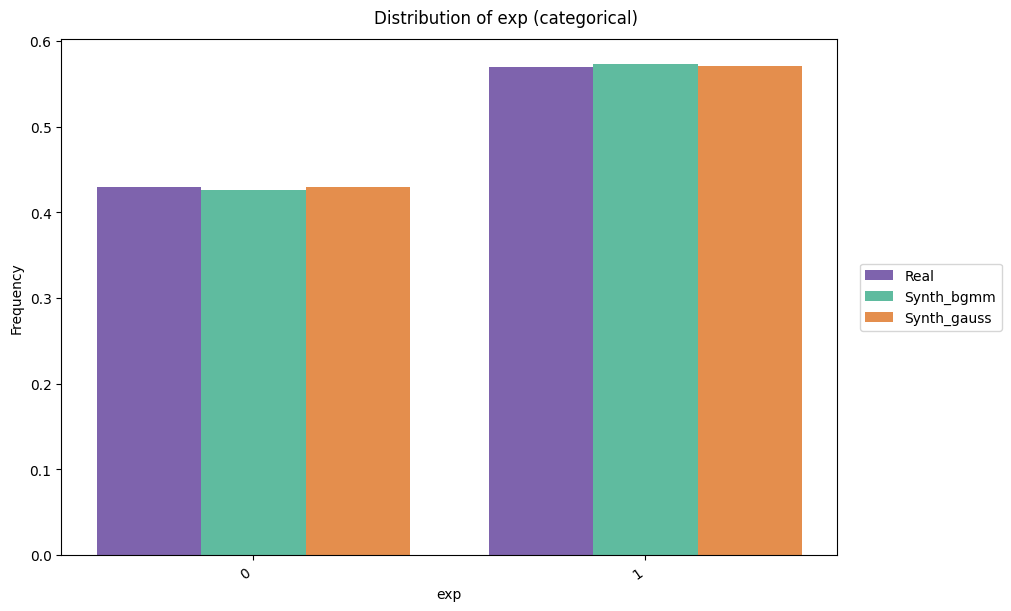

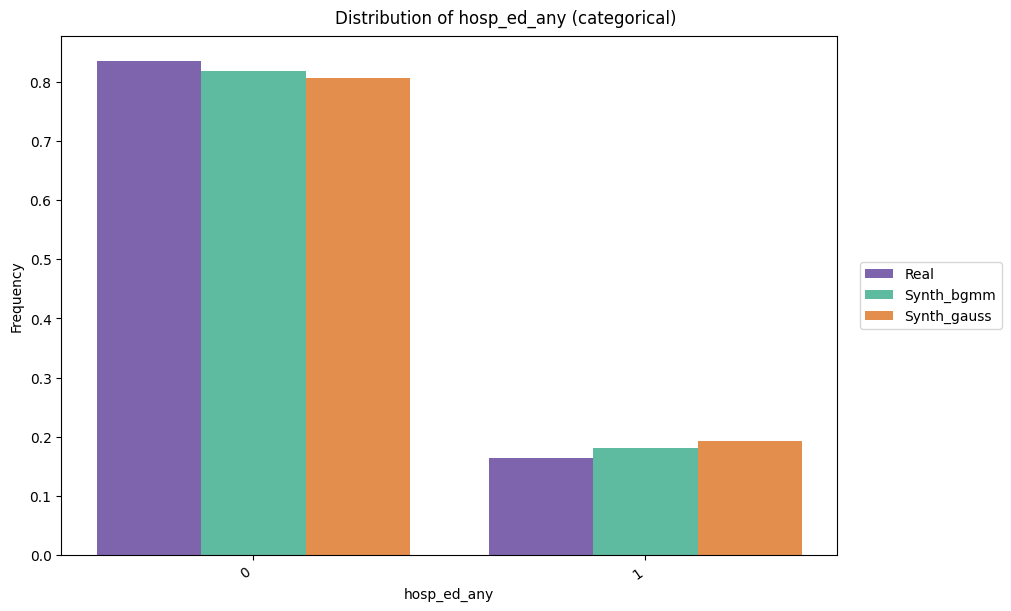

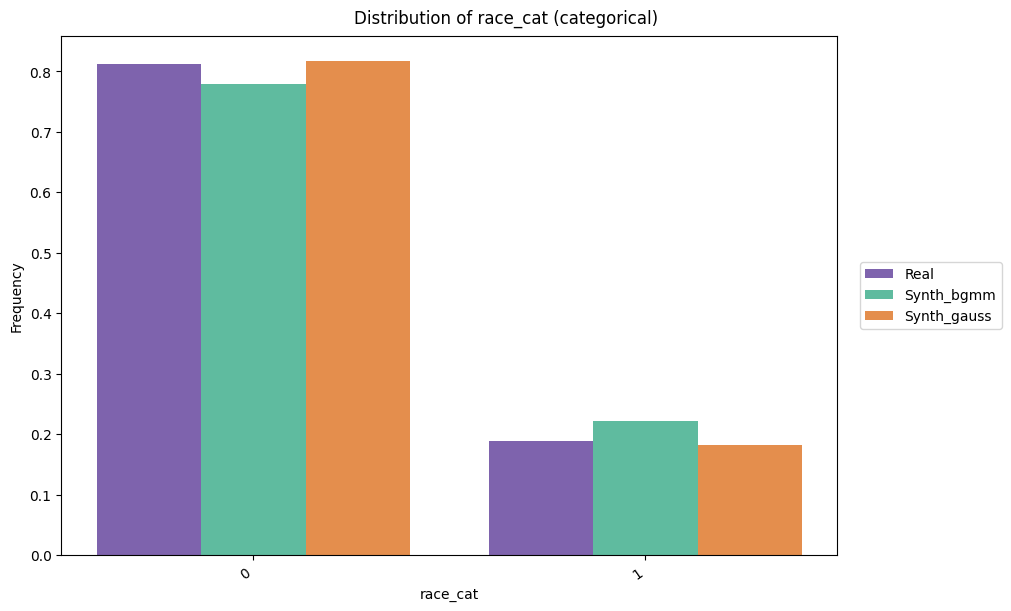

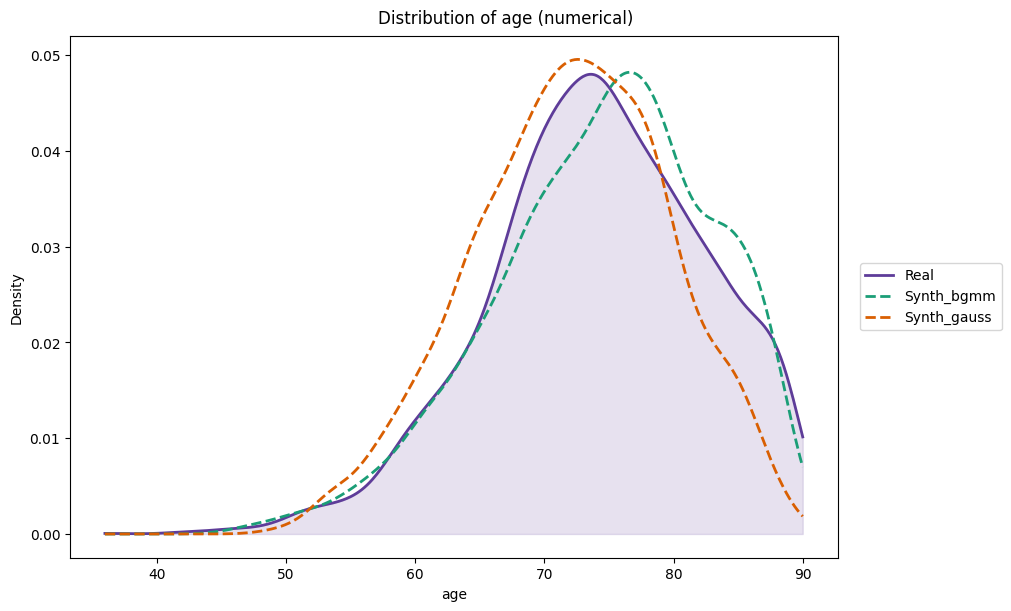

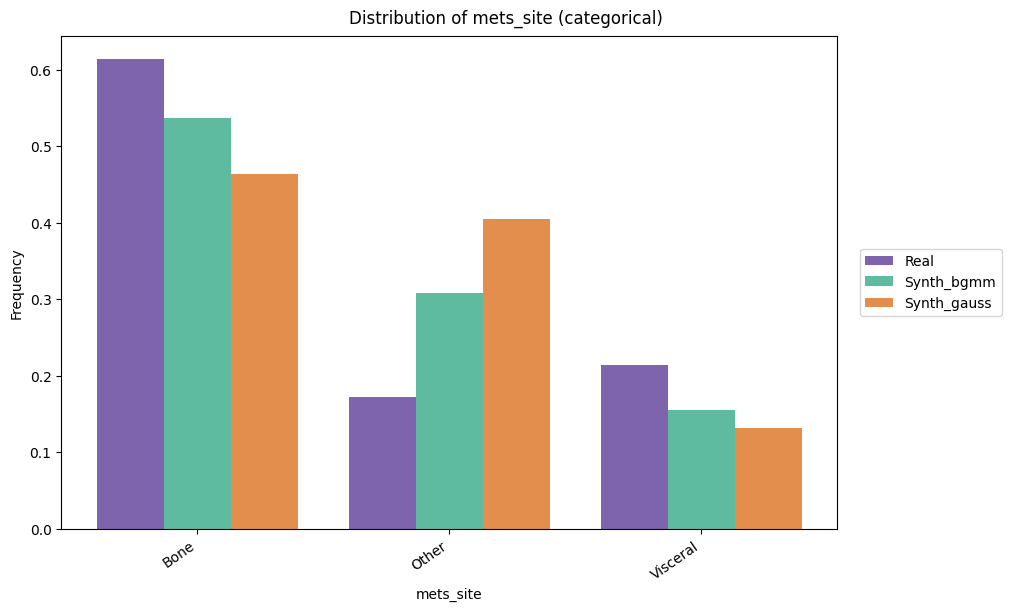

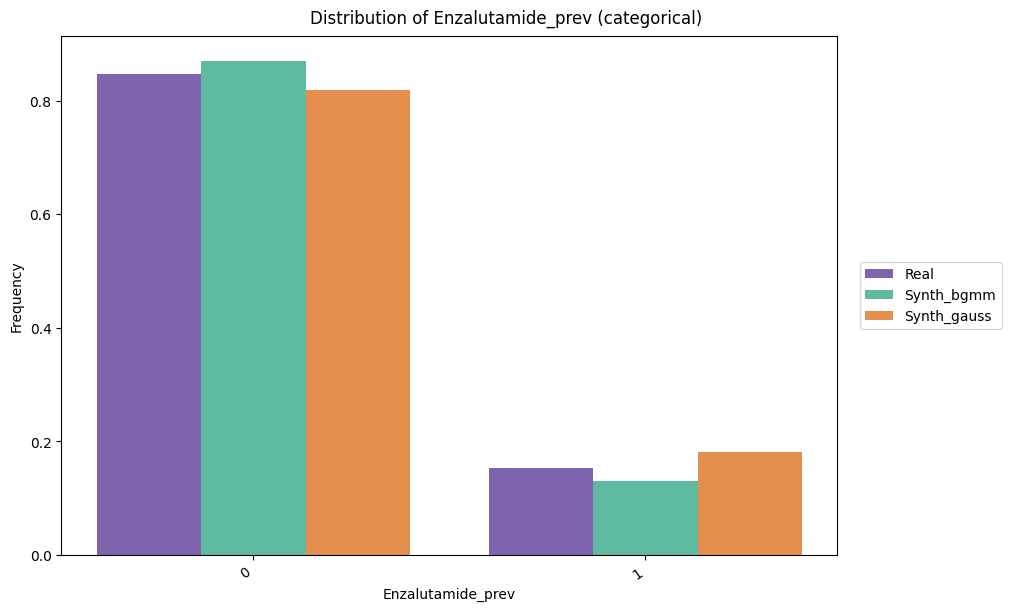

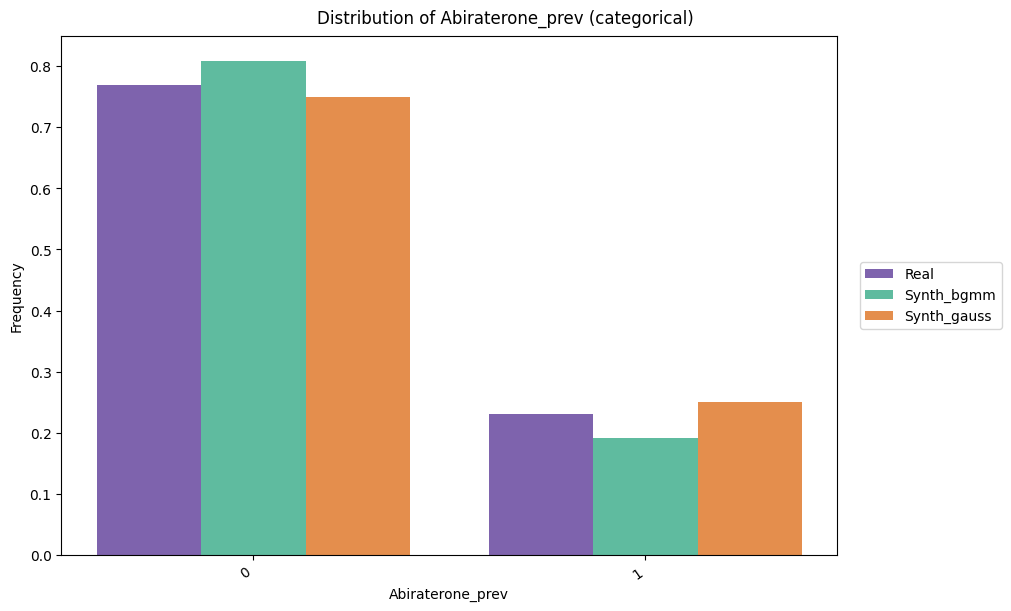

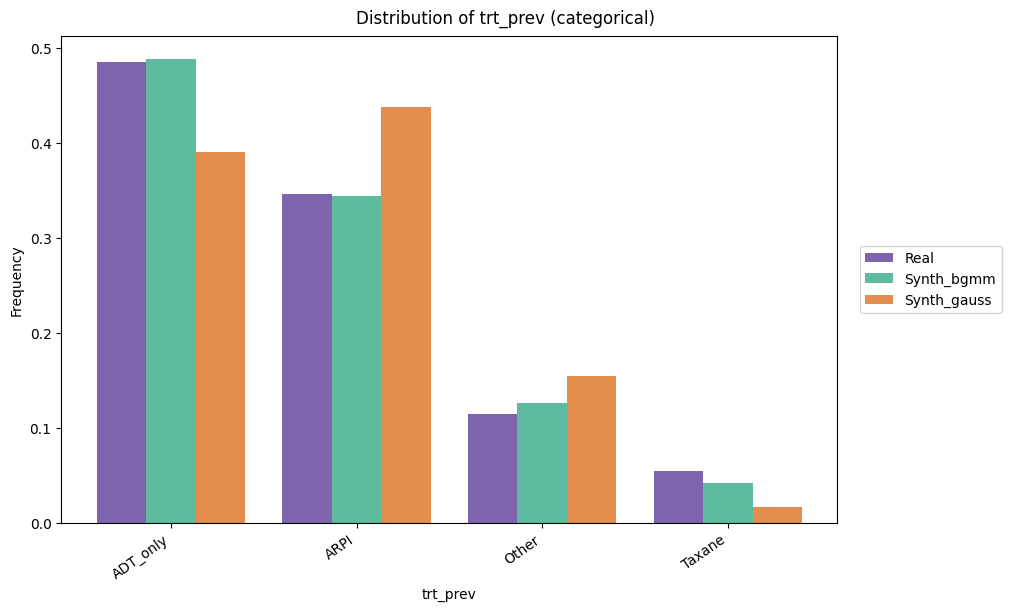

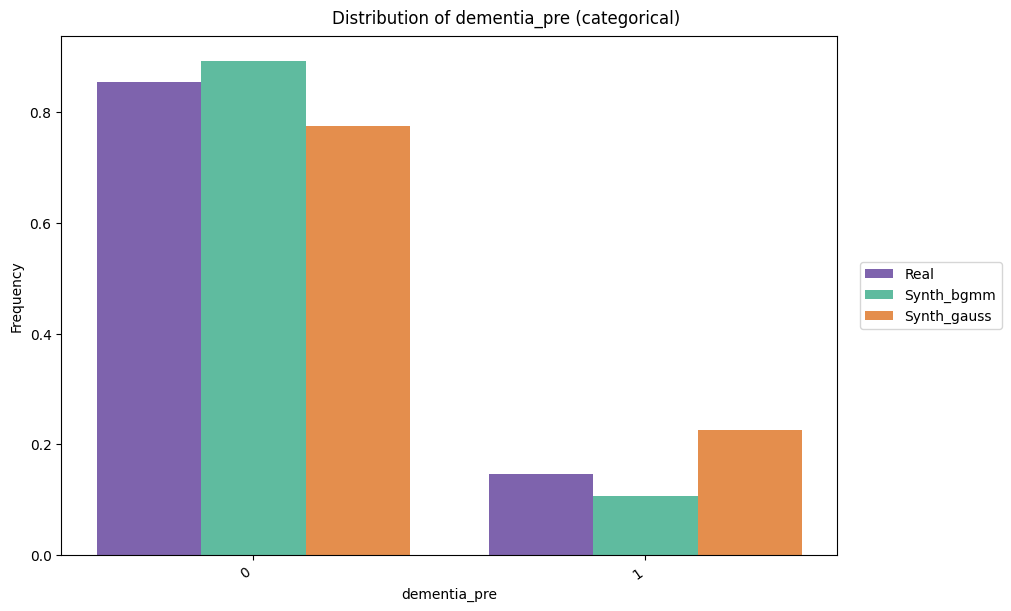

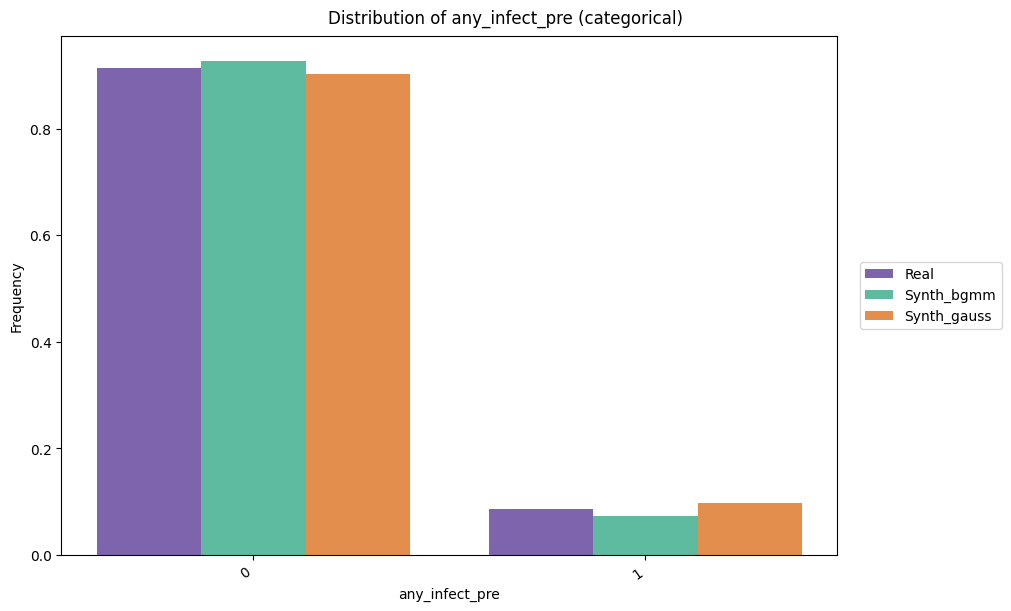

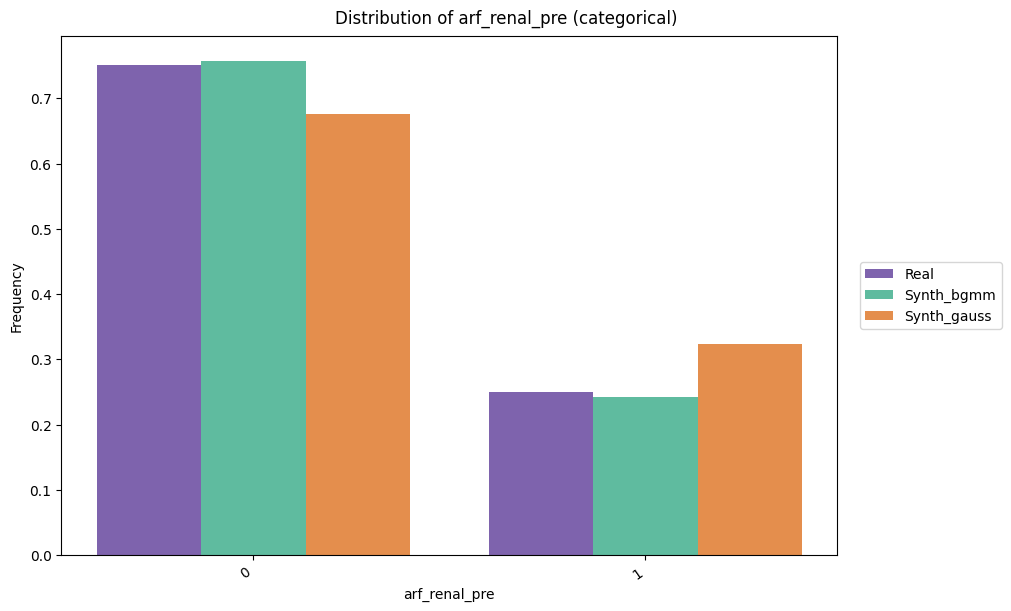

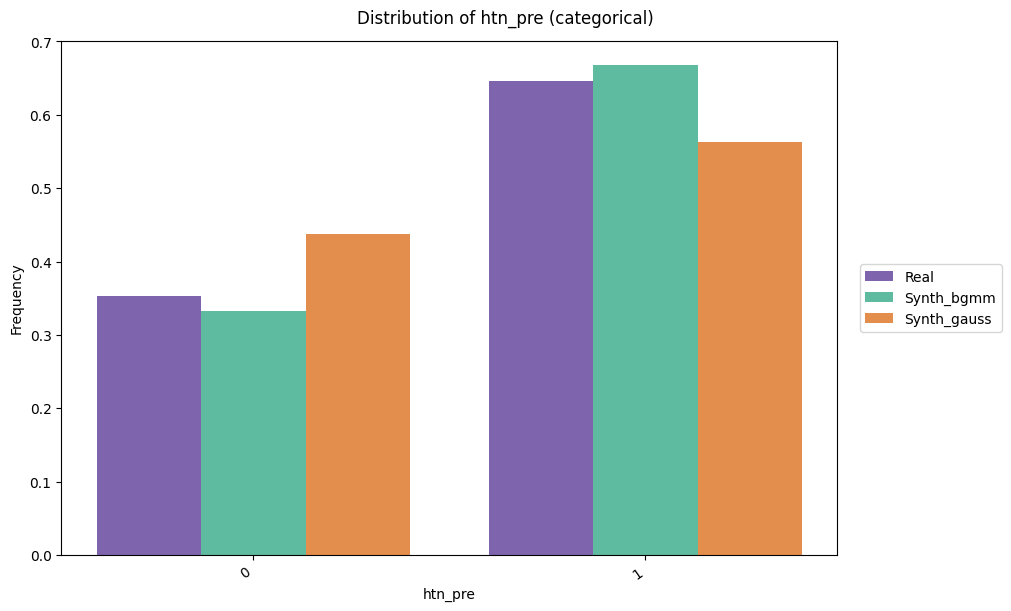

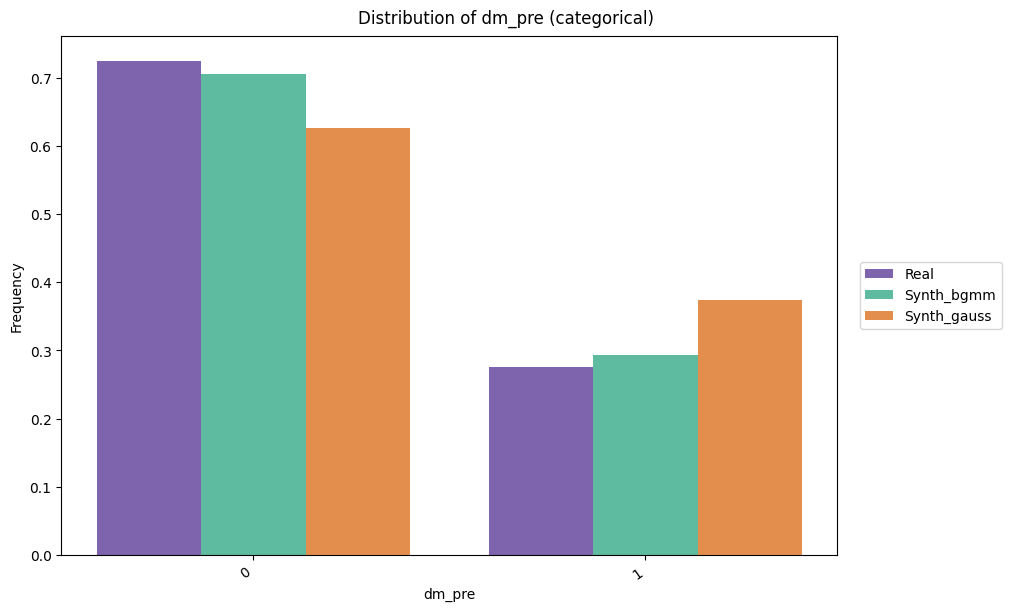

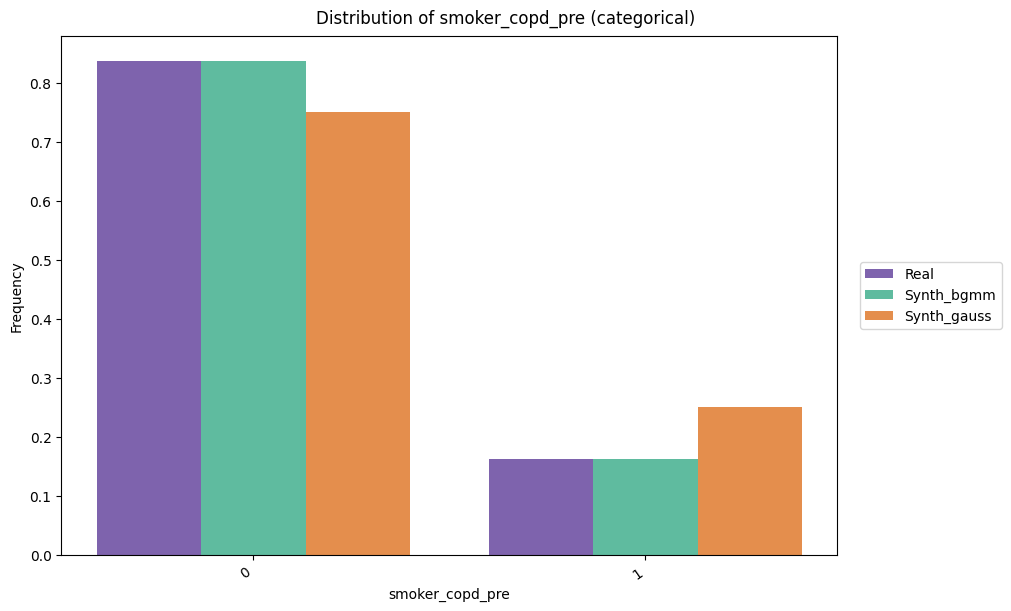

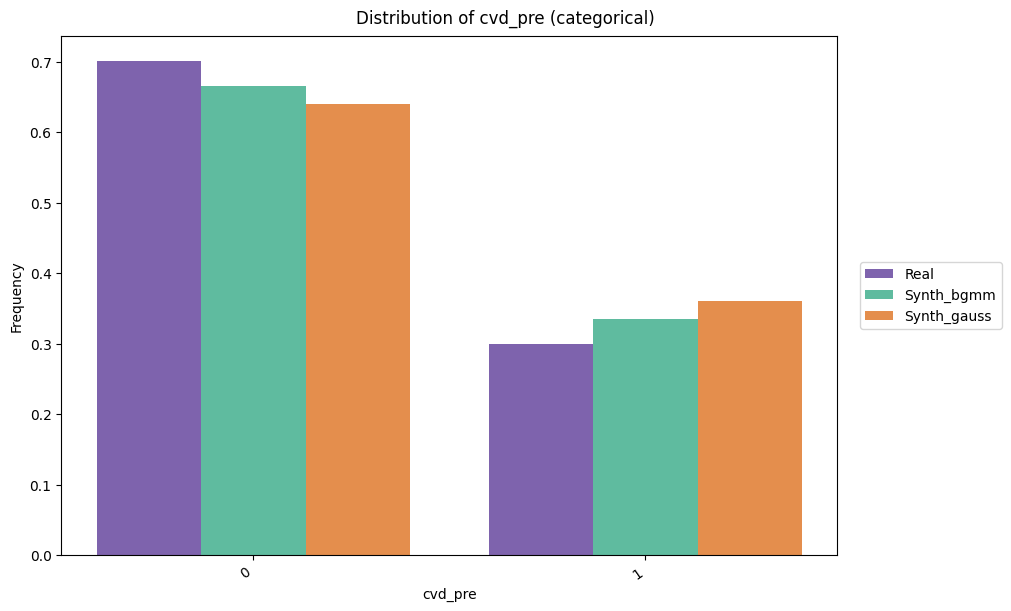

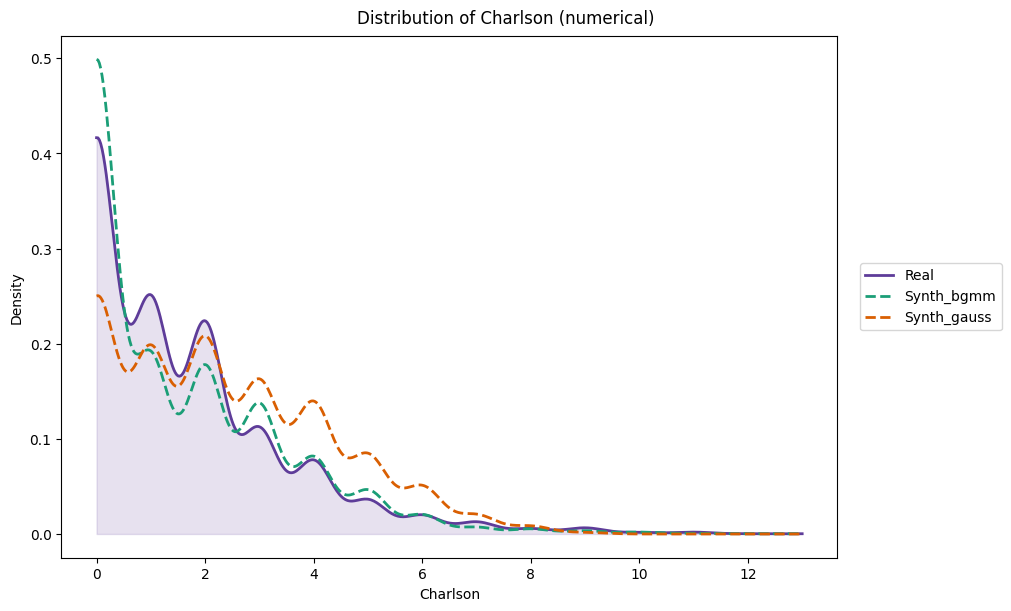

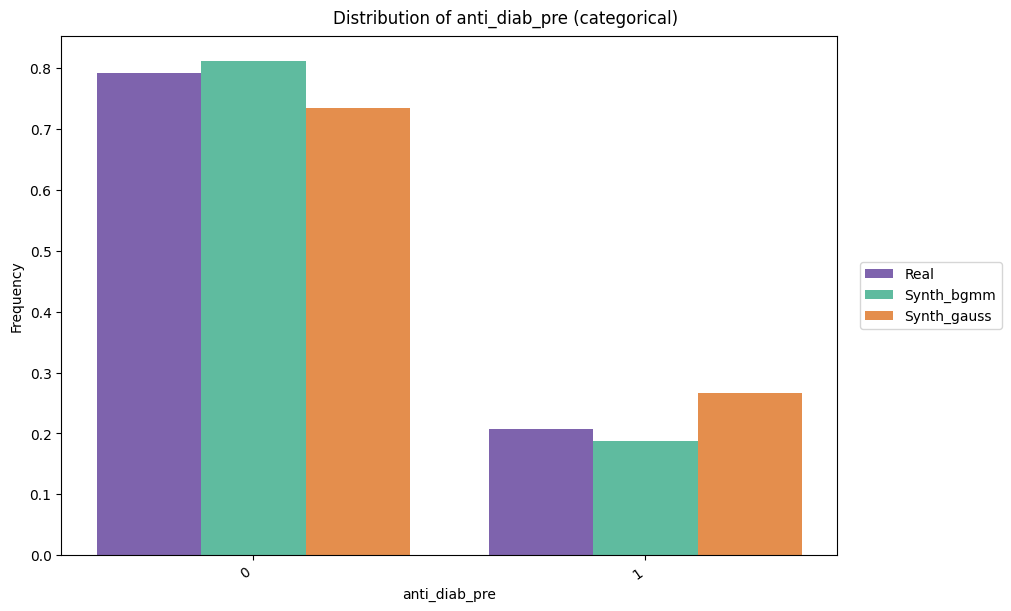

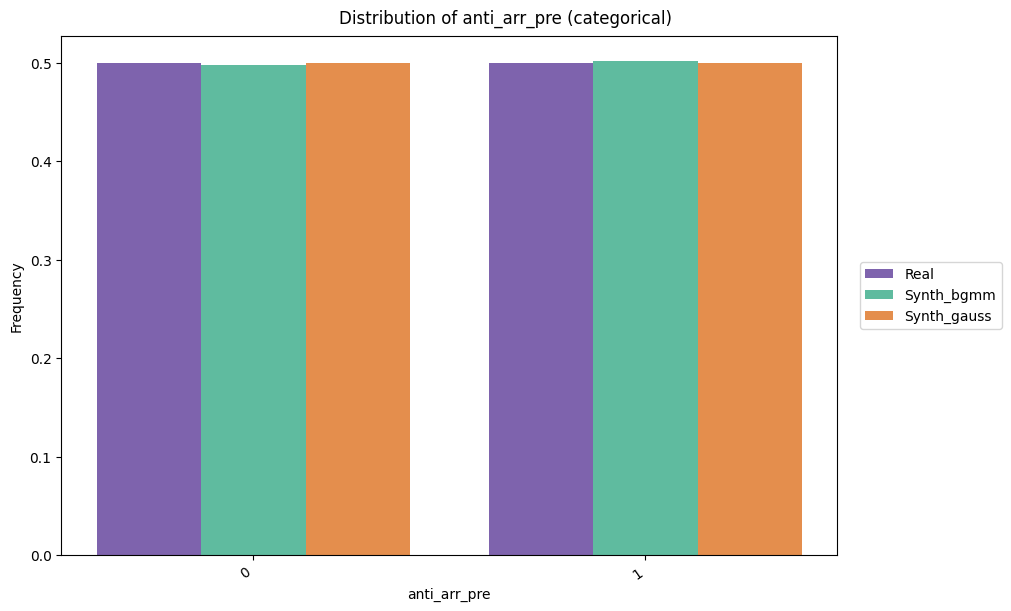

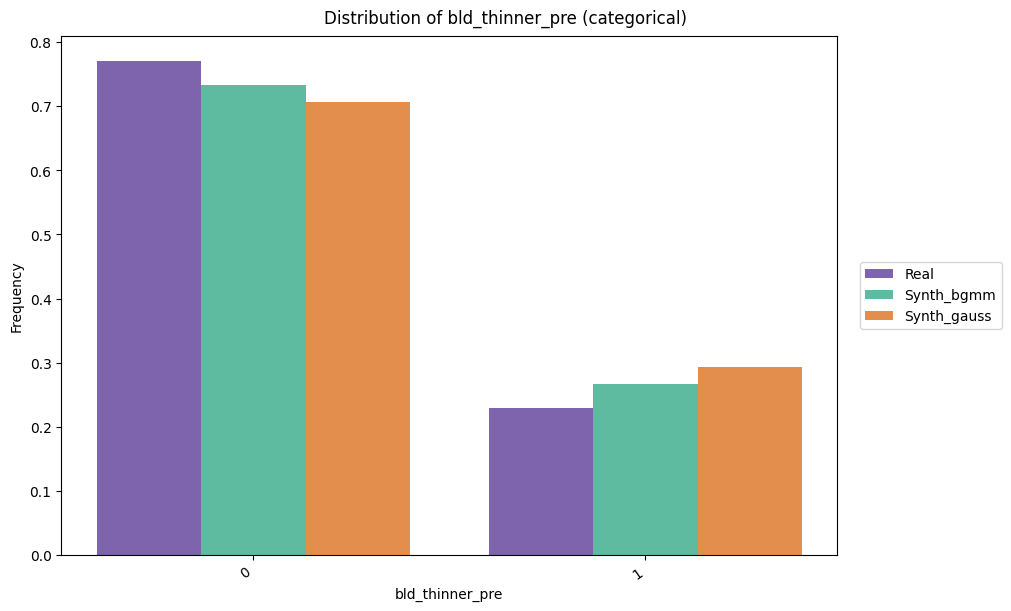

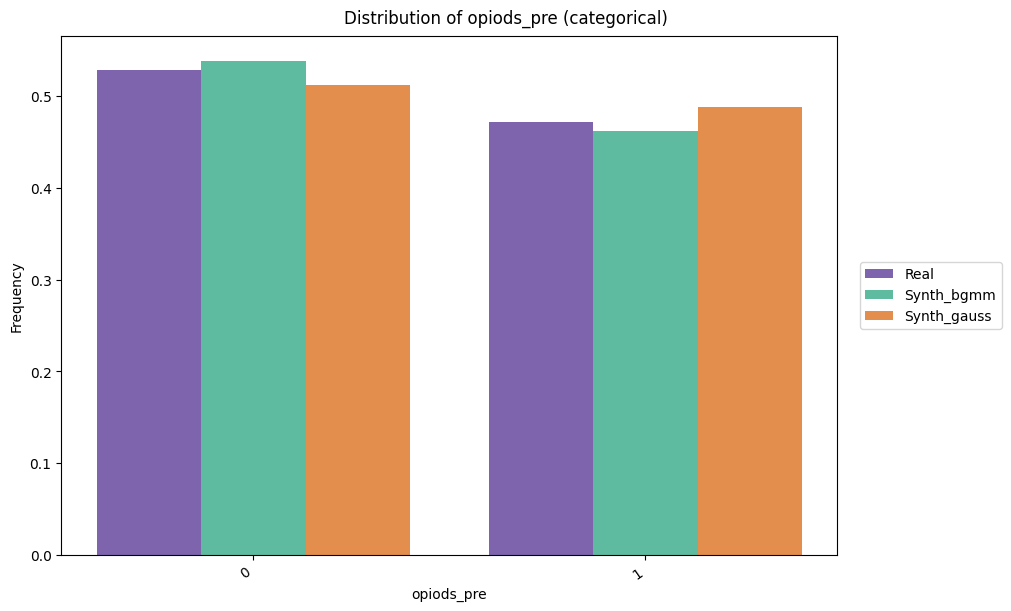

In [0]:
# check the distribution plots
synth_dict = {
    "Synth_bgmm": out1_bgmm["df_gen"],
    "Synth_gauss": out1_gauss["df_gen"]
}
# single column plots
for var in mcrpc_data.columns:
    fig = single_column_plot(
        real_data=mcrpc_data,
        synthetic_data=synth_dict,
        schema=schema,
        column_name=var,
        #main_title="Marginal distribution of age",
        x_label=var,
        y_label=None,
        fig_size=(10,6),
        legend_outside=True,
        #show_hist = True,
    )
    # save figure to pdf
    #fig.savefig(output_result + "column_" + var + ".pdf")
    fig.show()

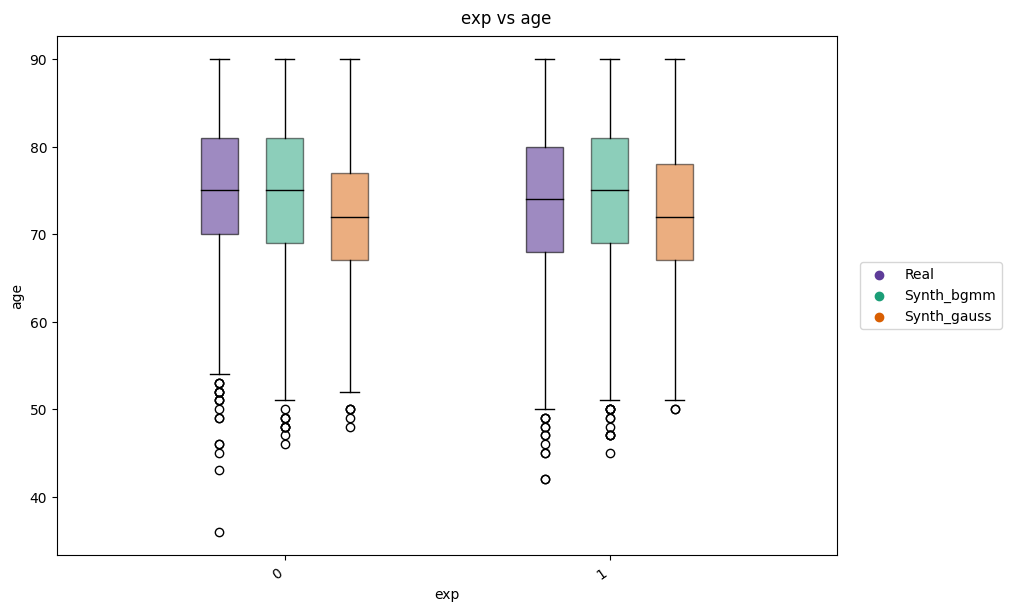

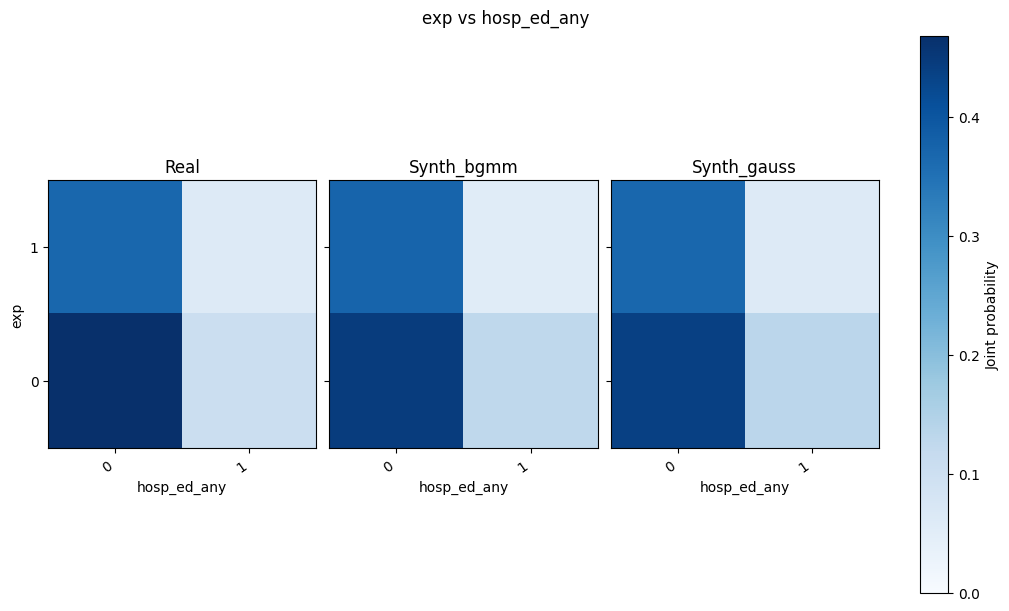

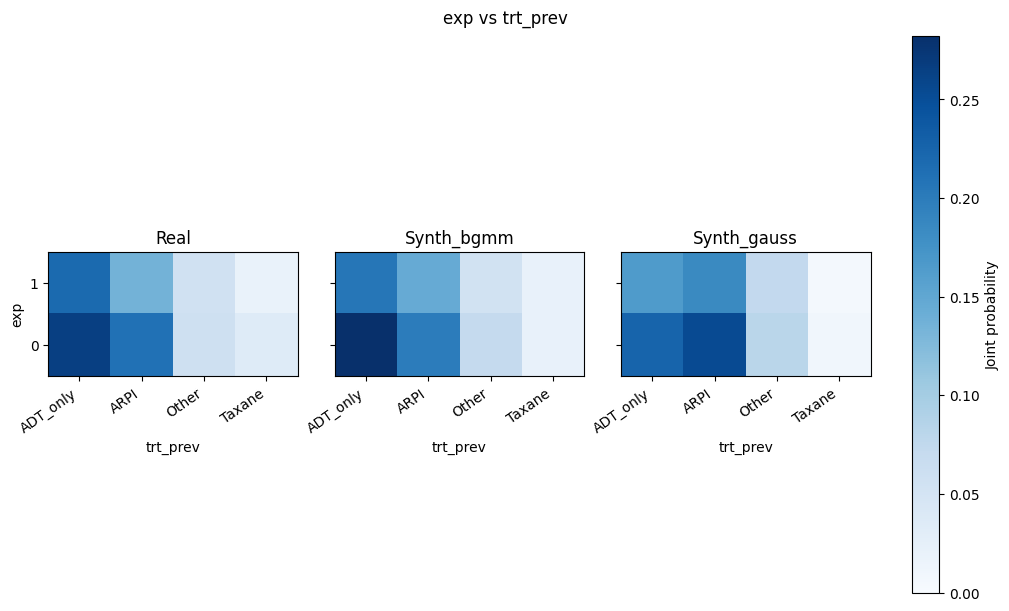

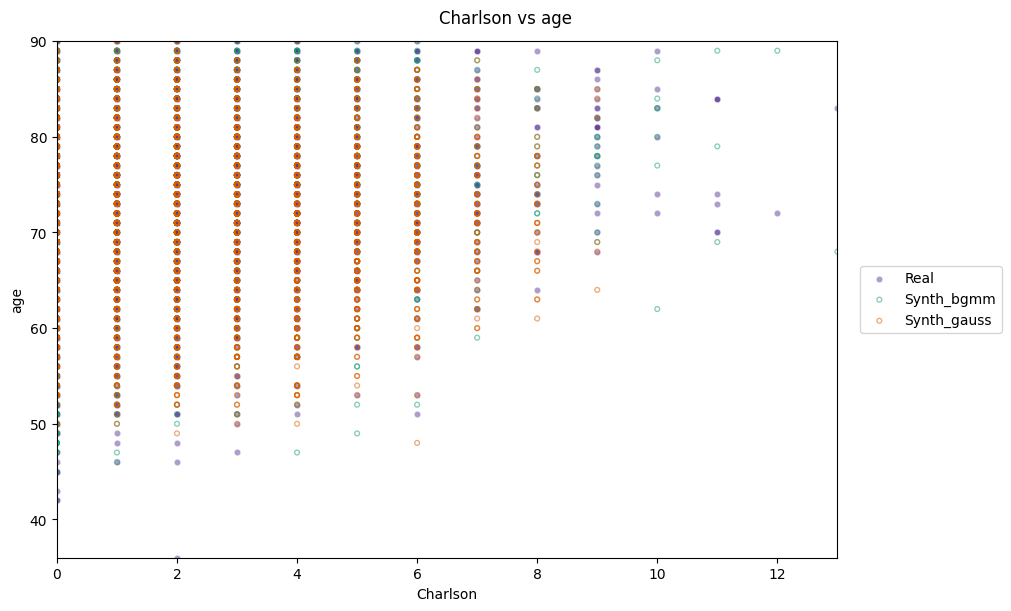

In [0]:
# pair column plots
column_names = [["exp", "age"], ["exp", "hosp_ed_any"], ["exp", "trt_prev"], ["Charlson", "age"]]
for pair in column_names:
    fig = pair_column_plot(
        real_data=mcrpc_data,
        synthetic_data=synth_dict,
        schema=schema,
        column_names=pair,
        #main_title="Marginal distribution of age",
        x_label=None,
        y_label=None,
        fig_size=(10,6),
        legend_outside=True,
        #show_hist = True,
    )
    # save figure to pdf
    #fig.savefig(output_result + pair[0] + "_" + pair[1] + ".pdf")
    fig.show()